In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("/content/adult.csv")

In [3]:
df

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [5]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [6]:
df.shape

(48842, 15)

In [7]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [8]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [9]:
df.columns.tolist()

['age',
 'workclass',
 'fnlwgt',
 'education',
 'educational-num',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'gender',
 'capital-gain',
 'capital-loss',
 'hours-per-week',
 'native-country',
 'income']

In [10]:
df.dtypes

,0
age,int64
workclass,object
fnlwgt,int64
education,object
educational-num,int64
marital-status,object
occupation,object
relationship,object
race,object
gender,object


In [11]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


In [12]:
df.duplicated().sum()

np.int64(52)

In [13]:
df["income"].value_counts()

,count
income,
<=50K,37155
>50K,11687


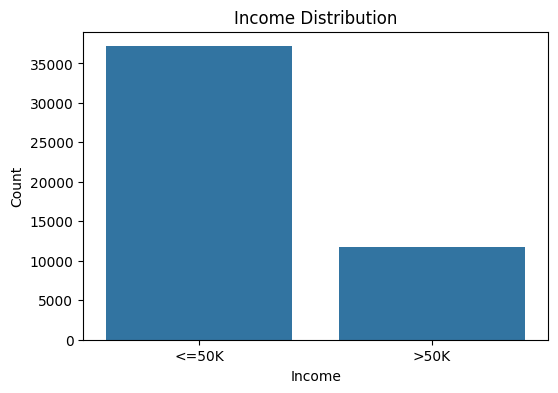

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="income")
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

**Most people (76%) earn ≤50K, while only 24% earn >50K. So, the data is unbalanced.**


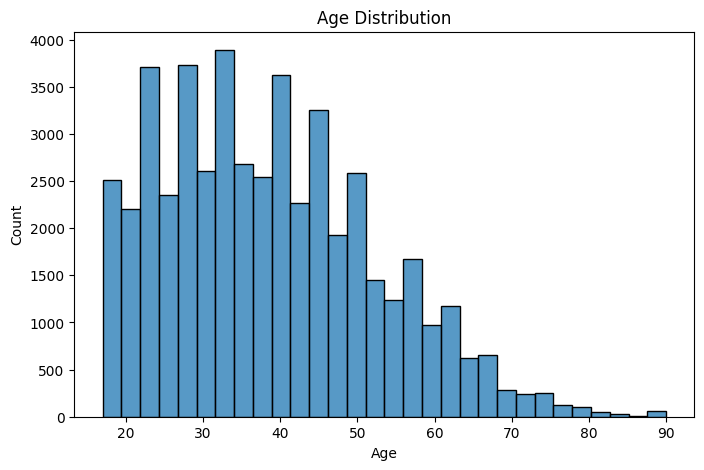

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

**Most people are 20–45 years old. There are fewer older people, especially over 70.**


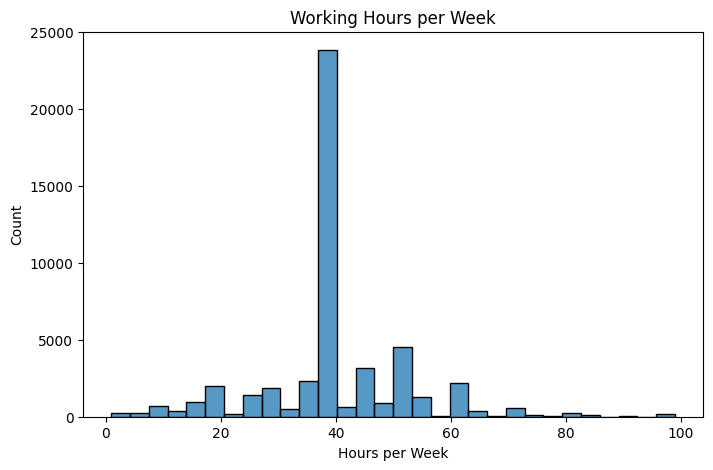

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df["hours-per-week"], bins=30)
plt.title("Working Hours per Week")
plt.xlabel("Hours per Week")
plt.ylabel("Count")
plt.show()

**Most people work about 40 hours per week. Fewer people work around 20 or 50 hours.**


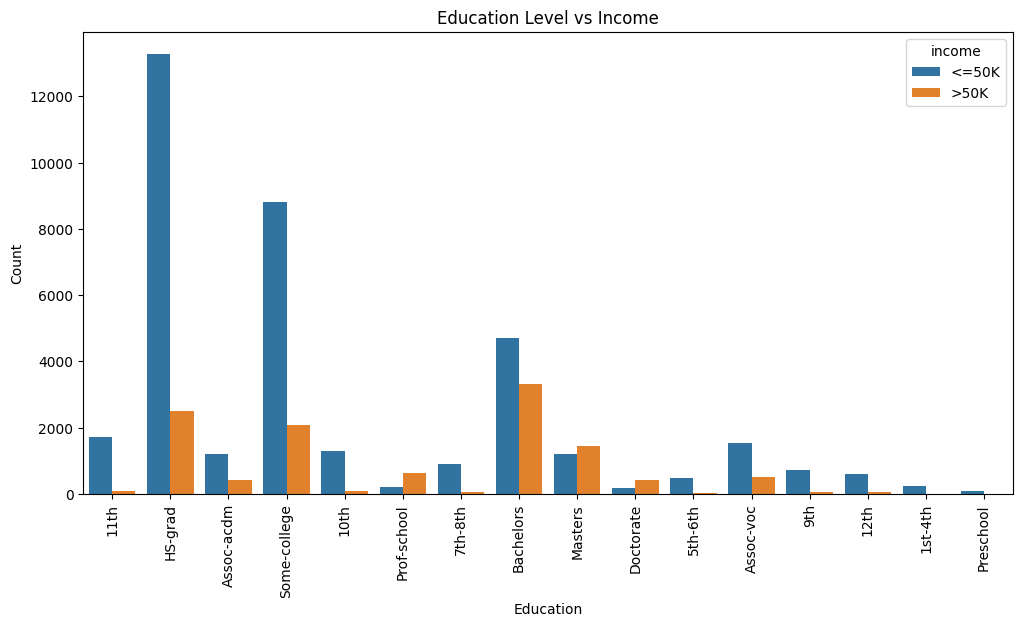

In [17]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="education", hue="income")
plt.xticks(rotation=90)
plt.title("Education Level vs Income")
plt.xlabel("Education")
plt.ylabel("Count")
plt.show()

**People with more education are more likely to earn >50K. Most people with lower education earn ≤50K.**


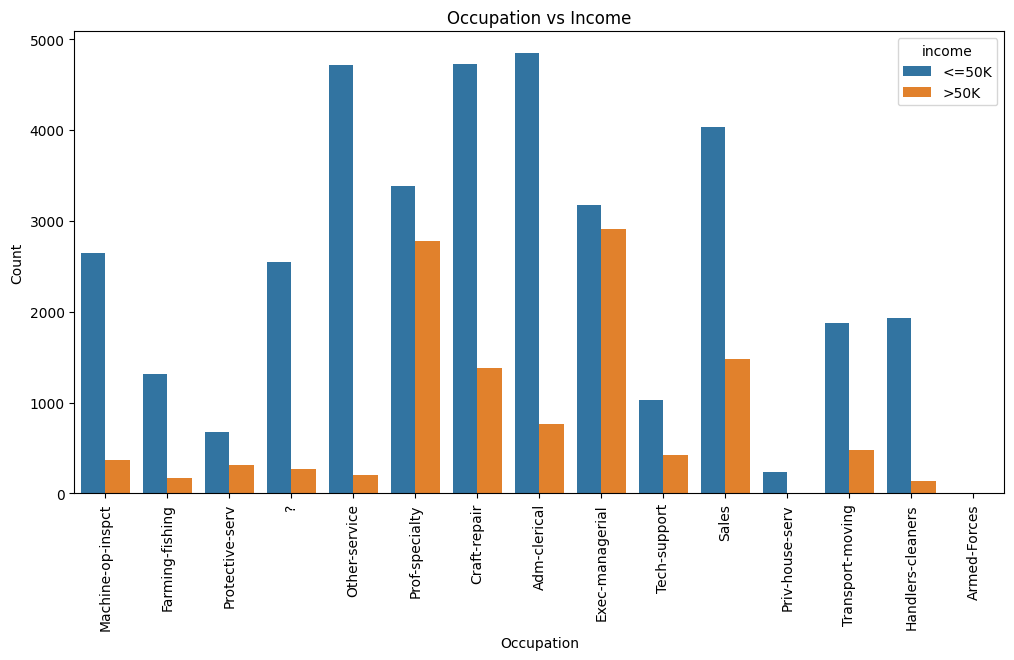

In [18]:
plt.figure(figsize=(12,6))
sns.countplot(data=df,x="occupation",hue="income")
plt.xticks(rotation=90)
plt.title("Occupation vs Income")
plt.xlabel("Occupation")
plt.ylabel("Count")
plt.show()

**Managers and professionals often earn >50K, while service and labor jobs usually earn less.**


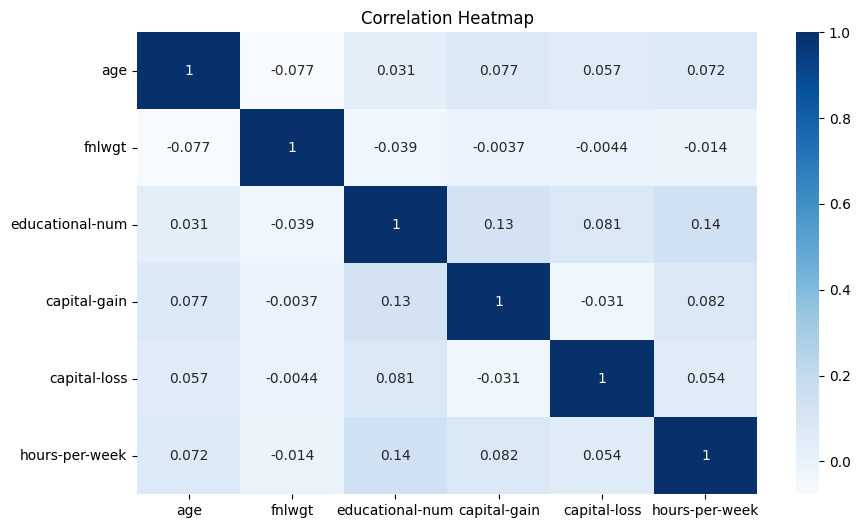

In [19]:
plt.figure(figsize=(10,6))
sns.heatmap( df.select_dtypes(include="number").corr(),annot=True,cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

**The features are mostly independent. This is good because each feature gives the model different information.**


In [20]:
for col in df.select_dtypes(include="object").columns:
    print(col, ":", (df[col] == "?").sum())

workclass : 2799
education : 0
marital-status : 0
occupation : 2809
relationship : 0
race : 0
gender : 0
native-country : 857
income : 0


**Three columns have missing data marked with "?". We need to fix or remove these values before using the data.**


In [21]:
df=df.replace("?", np.nan)
df

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


This code changes "?" into missing values (NaN) so they can be handled easily.


In [22]:
categorical_columns = df.select_dtypes(include="object").columns
for col in categorical_columns:
    if col != "income":
        df[col] = df[col].fillna(df[col].mode()[0])

In [23]:
df=df.dropna(subset=["income"])
df

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,Private,103497,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [24]:
df=df.drop_duplicates()
df

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,Private,103497,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


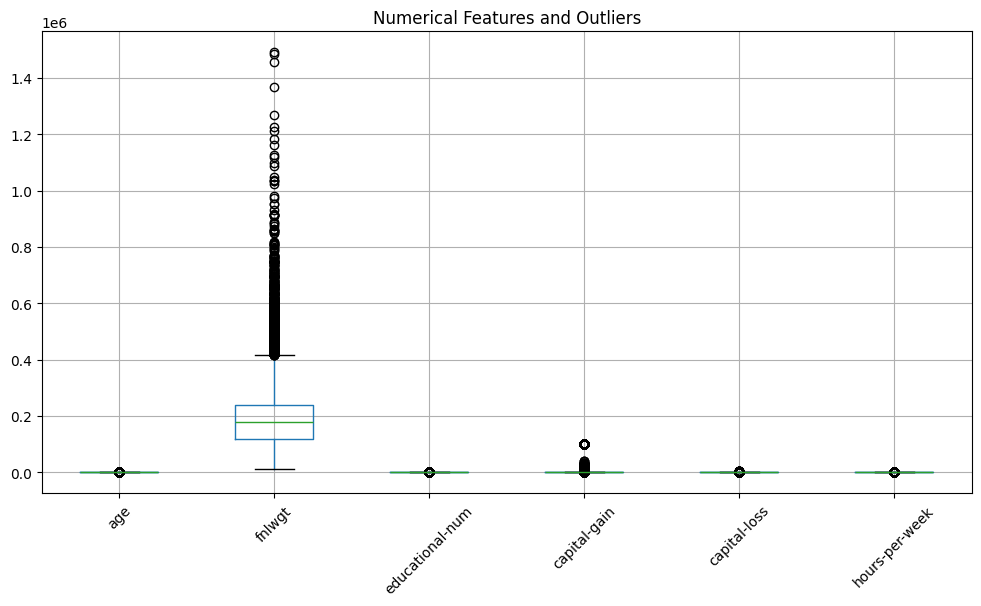

In [25]:
numeric_columns = df.select_dtypes(include="number").columns
plt.figure(figsize=(12,6))
df[numeric_columns].boxplot()
plt.xticks(rotation=45)
plt.title("Numerical Features and Outliers")
plt.show()

**Here one column, “fnlwgt,” has very large values, which makes the other columns look very small on the chart.**


In [26]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 25, 35, 50, 100],
    labels=["Young", "Adult", "Middle_Age", "Senior"]
)

df["capital_net"] = df["capital-gain"] - df["capital-loss"]

df["hours_group"] = pd.cut(
    df["hours-per-week"],
    bins=[0, 30, 40, 60, 100],
    labels=["Low", "Normal", "High", "Very_High"]
)


In [27]:
X = df.drop("income", axis=1)
y = df["income"]

In [28]:
X_train,X_test,y_train,y_test =train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (39031, 17)
Testing data: (9758, 17)


In [29]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

In [30]:
numeric_features

['age',
 'fnlwgt',
 'educational-num',
 'capital-gain',
 'capital-loss',
 'hours-per-week',
 'capital_net']

In [31]:
categorical_features

['workclass',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'gender',
 'native-country',
 'age_group',
 'hours_group']

In [32]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [33]:
models = {
   "Logistic Regression": LogisticRegression(max_iter=1000),
   "Decision Tree": DecisionTreeClassifier(random_state=42),
   "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

In [34]:
results = []
trained_models = {}

for name, model in models.items():
    pipeline = Pipeline([("preprocessing", preprocessor),("model", model)])
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=">50K")
    recall = recall_score(y_test, y_pred, pos_label=">50K")
    f1 = f1_score(y_test, y_pred, pos_label=">50K")

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    trained_models[name] = pipeline

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.851404,0.731695,0.598887,0.658663
1,Decision Tree,0.809695,0.598357,0.623716,0.610773
2,Random Forest,0.850072,0.711585,0.628425,0.667424


In [35]:
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8514,0.7317,0.5989,0.6587
1,Decision Tree,0.8097,0.5984,0.6237,0.6108
2,Random Forest,0.8501,0.7116,0.6284,0.6674


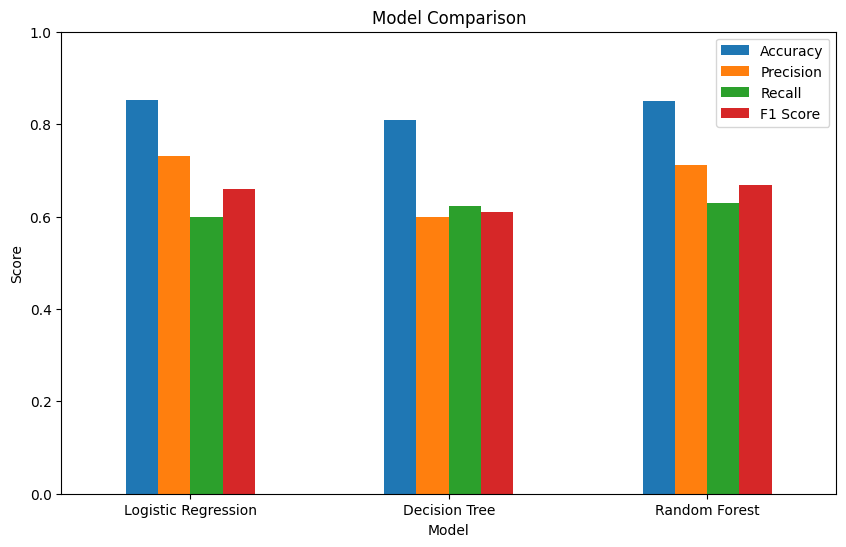

In [36]:
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

**Random Forest performs the best, with the highest accuracy and F1 score. Decision Tree performs the weakest among the three models.**


In [37]:
from sklearn.model_selection import cross_val_score

cv_results = []
for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="f1_weighted"
    )

    cv_results.append({
        "Model": name,
        "CV F1 Mean": scores.mean(),
        "CV F1 Std": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df.round(4)

,Model,CV F1 Mean,CV F1 Std
0,Logistic Regression,0.8511,0.0044
1,Decision Tree,0.8154,0.0022
2,Random Forest,0.8484,0.0012


In [38]:
best_model_name = results_df.loc[
    results_df["F1 Score"].idxmax(),
    "Model"
]


In [39]:
best_model_name

'Random Forest'

In [40]:
final_model = trained_models[best_model_name]
print("Final model:", best_model_name)

Final model: Random Forest


In [41]:
y_pred = final_model.predict(X_test)
report = classification_report(y_test,y_pred,output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df = report_df.round(2)

report_df

,precision,recall,f1-score,support
<=50K,0.89,0.92,0.90,7422.00
>50K,0.71,0.63,0.67,2336.00
accuracy,0.85,0.85,0.85,0.85
macro avg,0.80,0.77,0.79,9758.00
weighted avg,0.85,0.85,0.85,9758.00


In [42]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["<=50K", ">50K"]
)


In [43]:
cm

array([[6827,  595],
       [ 868, 1468]])

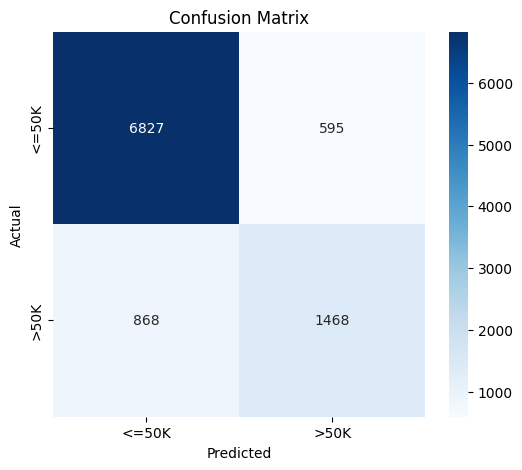

In [44]:
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["<=50K", ">50K"],
    yticklabels=["<=50K", ">50K"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**The model is about 85% accurate, but it often misses people earning >50K. It predicts ≤50K better because there are more people in that group.**


In [45]:
joblib.dump(final_model, "adult_income_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [46]:
loaded_model = joblib.load("adult_income_model.pkl")
test_prediction = loaded_model.predict(X_test.iloc[:5])

test_prediction


array(['>50K', '<=50K', '<=50K', '<=50K', '<=50K'], dtype=object)